In [13]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# cargar datos
data = pd.read_csv('../star_classification.csv')

# Analisis exploratorio del dataset

In [15]:
# visualizacion del dataset

# 1) imprimir columnas
columnas = data.columns.tolist()
print(columnas)

# 2) ver las dimensiones del dataset
print(f'dimension del dataset (fila x columna): {data.shape}')

['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']
dimension del dataset (fila x columna): (100000, 18)


In [16]:
# 3) ver si hay nulos en el dataset
nulos = data.isnull().sum()
print(f'cantidad de nulos: {nulos}')

cantidad de nulos: obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [17]:
# 4) ver los tipos de cada columna para luego usar el clasificador
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

# EDA

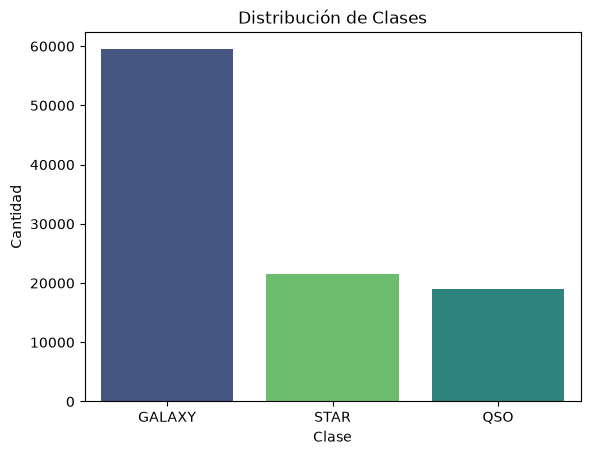

In [18]:
# ver la dstribucion entre las clases de los objetos astronomicos
sns.countplot(data=data, x='class', hue='class', legend=False, palette='viridis', order=data['class'].value_counts().index)
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

En base a este grafico se puede observar que la mayoria de los datos que hay son de Galaxias con casi 60 mil muestras, luego de Estrellas o de Quasares hay aproximadamente 20 mil de cada clase, por lo que el modelo tendra mas informacion sobre galaxias que las otras dos para poder entrenar.

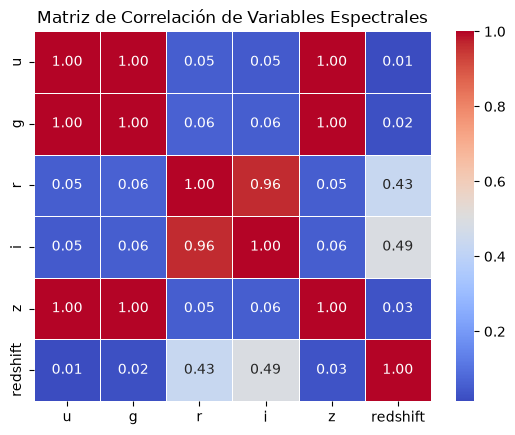

In [19]:
# Matriz de correlacion
caracteristicas = ['u', 'g', 'r', 'i', 'z', 'redshift']

matriz_corr = data[caracteristicas].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Espectrales')
plt.show()

Aca se puede apreciar que variables estan relacionadas entre si, mientras mas rojo y mas cerca del 1 mas relacionadas estan. Por ejemplo, se puede ver que los filtros de luz 'r' e 'i' tienen un 0.96 de relacion, son casi lo mismo para el modelo, en cambio, el redshift casi ni se relaciona con los filtros de luz y su indice es bajo.

# Clasificador

In [20]:
# Separar datos para predecir
caracteristicas = [      
                    'u',            #luz ultravioleta       
                    'g',            #luz verde
                    'r',            #luz roja       
                    'i',            #infrarrojo cercano       
                    'z',            #infrarrojo profundo           
                    'redshift'      #para ver que tan rapido se aleja el objeto
]

X = data[caracteristicas]
Y = data['class']

In [21]:
# division de datos para entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

### Random Forest

In [22]:
# configurar y entrenar el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=1)
modelo.fit(X_train, y_train)

# hacr predicciones con el conjunto de prueba
y_pred = modelo.predict(X_test)

# evaluar los resultados

# matriz de confusion
print("Matriz de confusion")
print(confusion_matrix(y_test, y_pred))

# precision del modelo
precision_modelo = accuracy_score(y_test, y_pred)
print(f"\nPrecisión del modelo: {precision_modelo:.2f}")

# mtricas de rendimiento
print("\nReporte de clasificacion:")
print(classification_report(y_test, y_pred))

Matriz de confusion
[[11733   121    17]
 [  251  3570     0]
 [    5     0  4303]]

Precisión del modelo: 0.98

Reporte de clasificacion:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11871
         QSO       0.97      0.93      0.95      3821
        STAR       1.00      1.00      1.00      4308

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



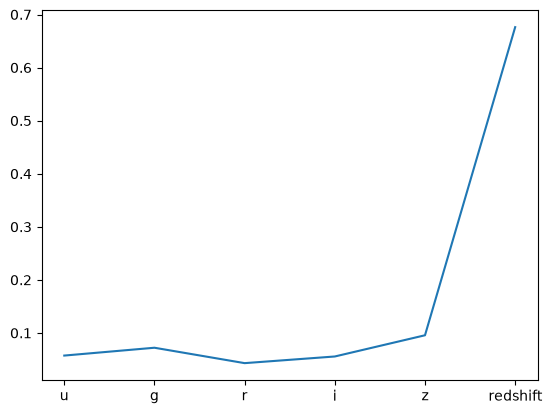

In [23]:
# ver la importancia de los atributos
importancia = modelo.feature_importances_
plt.plot(X_train.columns, importancia)
plt.show()

# Clasificación de un nuevo objeto

Esta función sirve para clasificar un nuevo objeto astronómico (GALAXY, QSO o STAR) a partir de sus magnitudes y su redshift, usando el modelo ya entrenado.

In [27]:
def clasificar_objeto(u, g, r, i, z, redshift):
    """
    Parámetros:
        u (int o float): magnitud en la banda ultravioleta.
        g (int o float): magnitud en la banda verde.
        r (int o float): magnitud en la banda roja.
        i (int o float): magnitud en la banda infrarroja cercana.
        z (int o float): magnitud en la banda infrarroja.
        redshift (int o float): corrimiento al rojo del objeto.

    Retorna:
        dict: diccionario con dos claves:
            'clase_predicha' (str): la clase predicha por el modelo
                ('GALAXY', 'QSO' o 'STAR').
            'probabilidades' (dict): probabilidad asociada a cada clase,
                como valores float nativos de Python redondeados a 4
                decimales para facilitar su lectura.
    """
    
    entradas = {'u': u, 'g': g, 'r': r, 'i': i, 'z': z, 'redshift': redshift}

    for nombre, valor in entradas.items():
        if not isinstance(valor, (int, float)) or isinstance(valor, bool):
            raise ValueError(f"El valor de '{nombre}' debe ser numérico, se recibió: {valor!r}")
        
    entrada_df = pd.DataFrame([entradas])[X_train.columns]

    clase_predicha = modelo.predict(entrada_df)[0]
    probabilidades = modelo.predict_proba(entrada_df)[0]
    prob_por_clase = {clase: round(float(prob), 4) for clase, prob in zip(modelo.classes_, probabilidades)}

    return {
        'clase_predicha': clase_predicha,
        'probabilidades': prob_por_clase
    }

### Pruebas de validación

Probaremos casos válidos e inválidos:
- Para los casos **válidos**, probaremos los tres tipos de cuerpo celeste.
- Para el caso **inválido** probaremos que salga un error al poner un valor no numérico.

In [28]:
# Casos válidos
casos = {
    'GALAXY': dict(u=22.795, g=21.646, r=20.054, i=19.179, z=18.739, redshift=0.519),
    'STAR':   dict(u=20.966, g=19.510, r=18.888, i=18.557, z=18.371, redshift=-0.001),
    'QSO':    dict(u=21.553, g=21.025, r=20.802, i=20.525, z=20.294, redshift=1.587),
}

for clase_real, valores in casos.items():
    resultado = clasificar_objeto(**valores)
    print(f"Clase real: {clase_real}")
    print(f"  Clase predicha: {resultado['clase_predicha']}")
    print(f"  Probabilidades: {resultado['probabilidades']}")
    print()

# Caso inválido
print('Caso con valor no numérico:')
try:
    clasificar_objeto(u='no es un número', g=20.0, r=19.0, i=18.5, z=18.0, redshift=0.1)
except ValueError as e:
    print(f'  Error capturado correctamente: {e}')

Clase real: GALAXY
  Clase predicha: GALAXY
  Probabilidades: {'GALAXY': 0.99, 'QSO': 0.01, 'STAR': 0.0}

Clase real: STAR
  Clase predicha: STAR
  Probabilidades: {'GALAXY': 0.0, 'QSO': 0.0, 'STAR': 1.0}

Clase real: QSO
  Clase predicha: QSO
  Probabilidades: {'GALAXY': 0.0, 'QSO': 1.0, 'STAR': 0.0}

Caso con valor no numérico:
  Error capturado correctamente: El valor de 'u' debe ser numérico, se recibió: 'no es un número'
